In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [2]:
# Display settings
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.head()

,User_ID,Age,Gender,Occupation,Sleep_Hours,Daily_Screen_Hours,Weekend_Screen_Hours,Social_Media_Hours,Caffeine_Cups_Per_Day,Work_Productivity_Score,App_Usage_Count,Exercise_Hours_Per_Week,Daily_Work_Hours,Commute_Hours_Per_Day,Stress_Level,Stressed
0,SR01502,27.0,male,healthcare worker,5.0,3.0,4.0,3.0,4.0,8.0,31.0,6.0,11.0,0.5,10,1
1,SR02587,28.0,female,healthcare worker,5.0,5.5,8.0,3.0,2.0,7.0,25.0,7.0,10.0,1.5,10,1
2,SR02654,29.0,male,freelancer,5.5,7.0,8.0,2.5,0.0,4.0,28.0,4.0,11.0,1.0,10,1
3,SR01056,28.0,other,teacher,9.0,3.5,5.0,3.5,3.0,5.0,34.0,1.0,14.0,0.5,10,1
4,SR00107,20.0,female,student,8.0,5.0,7.5,4.0,1.0,6.0,50.0,4.0,5.0,1.0,10,1


In [5]:
# Data types
print("Data Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n")
df.describe()

Data Types:

User_ID                     object
Age                        float64
Gender                      object
Occupation                  object
Sleep_Hours                float64
Daily_Screen_Hours         float64
Weekend_Screen_Hours       float64
Social_Media_Hours         float64
Caffeine_Cups_Per_Day      float64
Work_Productivity_Score    float64
App_Usage_Count            float64
Exercise_Hours_Per_Week    float64
Daily_Work_Hours           float64
Commute_Hours_Per_Day      float64
Stress_Level                 int64
Stressed                     int64
dtype: object

Missing Values:

User_ID                    0
Age                        0
Gender                     0
Occupation                 0
Sleep_Hours                0
Daily_Screen_Hours         0
Weekend_Screen_Hours       0
Social_Media_Hours         0
Caffeine_Cups_Per_Day      0
Work_Productivity_Score    0
App_Usage_Count            0
Exercise_Hours_Per_Week    0
Daily_Work_Hours           0
Commute_Hours_Per_

,Age,Sleep_Hours,Daily_Screen_Hours,Weekend_Screen_Hours,Social_Media_Hours,Caffeine_Cups_Per_Day,Work_Productivity_Score,App_Usage_Count,Exercise_Hours_Per_Week,Daily_Work_Hours,Commute_Hours_Per_Day,Stress_Level,Stressed
count,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000
mean,39.223654,6.887541,5.867956,7.607873,2.664680,2.207480,6.401567,30.304969,3.184737,7.138233,0.582783,8.372504,0.642911
std,17.466833,1.551969,2.521332,3.411310,1.678705,1.610181,1.796730,13.950862,2.068977,3.694576,0.518075,2.754210,0.479202
min,18.000000,0.500000,1.000000,1.000000,0.000000,-1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,6.000000,4.000000,5.000000,1.500000,1.000000,5.000000,21.000000,2.000000,4.000000,0.000000,7.000000,0.000000
50%,36.000000,7.000000,6.000000,7.500000,2.500000,2.000000,6.000000,31.000000,3.000000,7.138233,0.500000,10.000000,1.000000
75%,52.000000,8.000000,7.500000,10.000000,3.500000,3.000000,8.000000,40.000000,5.000000,10.000000,1.000000,10.000000,1.000000
max,85.000000,11.000000,14.000000,15.057845,9.000000,9.000000,10.000000,65.000000,10.000000,16.000000,2.500000,10.000000,1.000000


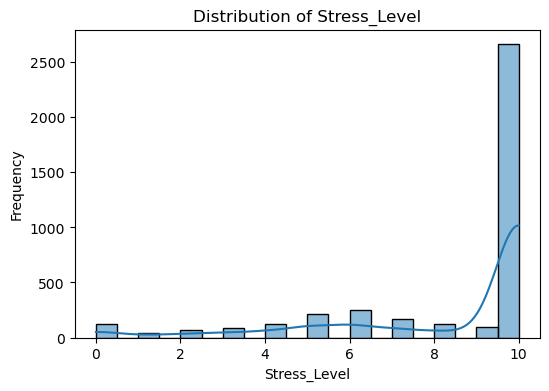

Skewness: -1.6056047230404917
Kurtosis: 1.5124484465038117

Summary:
 count    3957.000000
mean        8.372504
std         2.754210
min         0.000000
25%         7.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: Stress_Level, dtype: float64


In [6]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df["Stress_Level"], bins=20, kde=True)
plt.title("Distribution of Stress_Level")
plt.xlabel("Stress_Level")
plt.ylabel("Frequency")
plt.show()

# Statistical moments
stress_skew = skew(df["Stress_Level"])
stress_kurt = kurtosis(df["Stress_Level"])

print("Skewness:", stress_skew)
print("Kurtosis:", stress_kurt)
print("\nSummary:\n", df["Stress_Level"].describe())

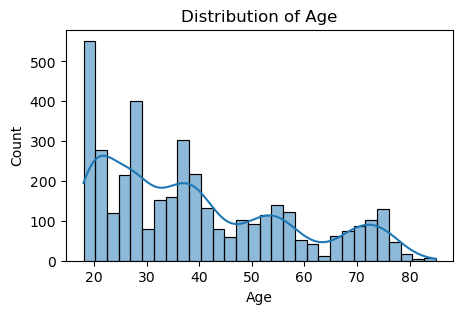

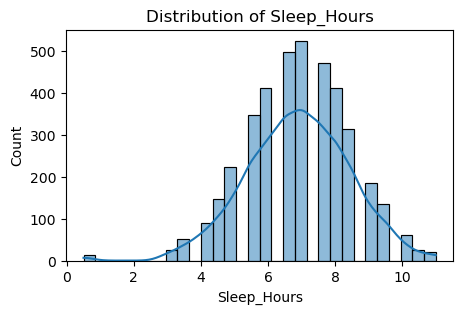

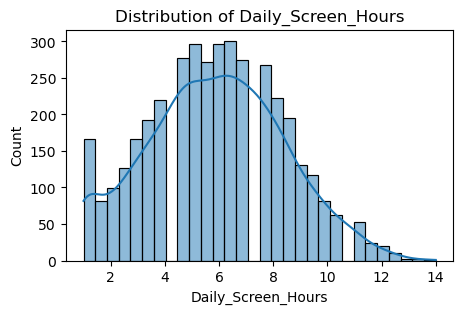

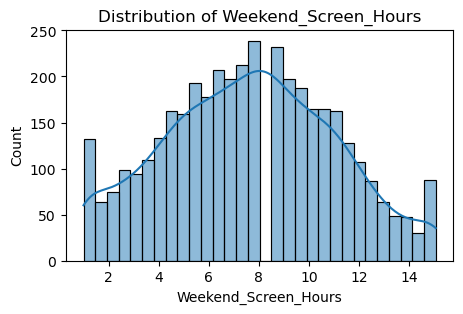

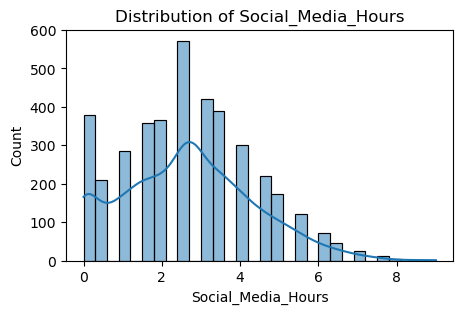

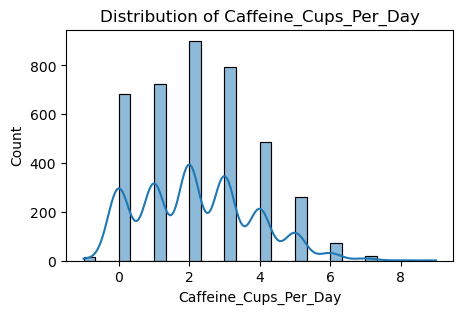

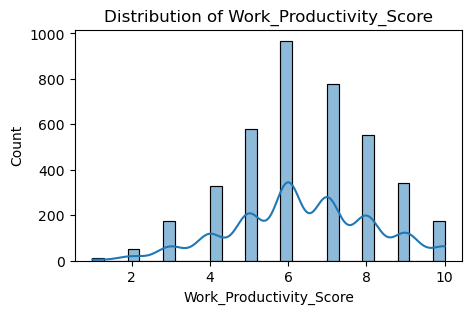

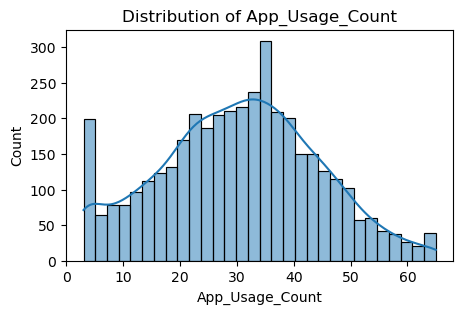

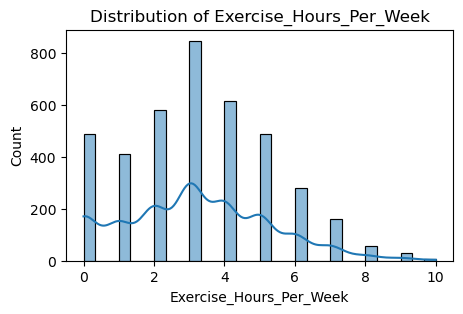

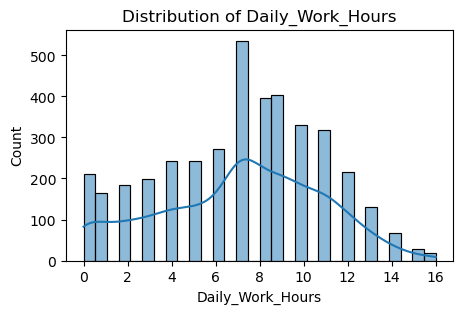

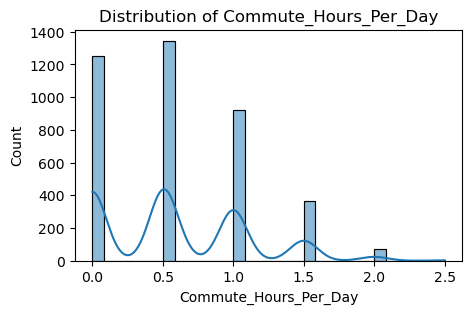

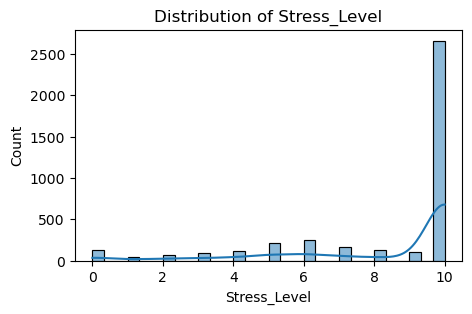

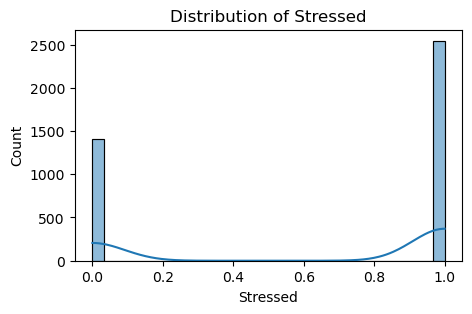

In [7]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

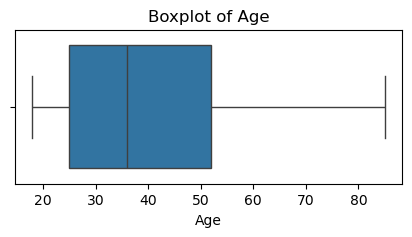

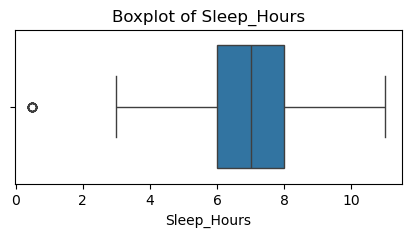

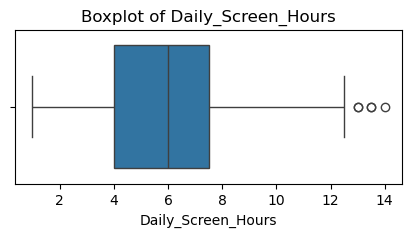

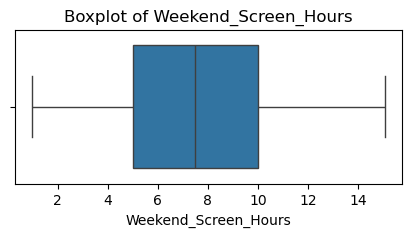

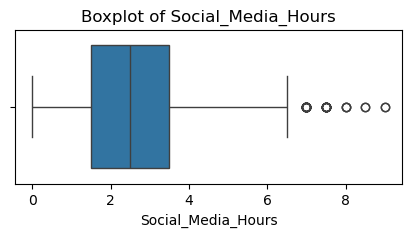

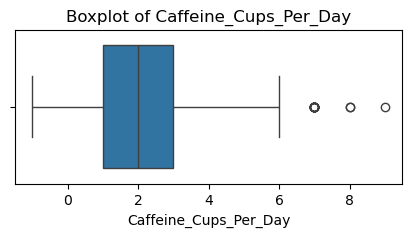

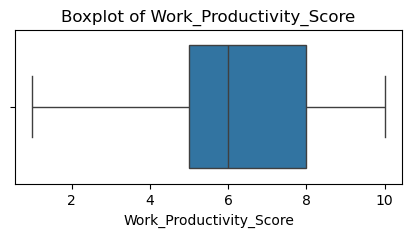

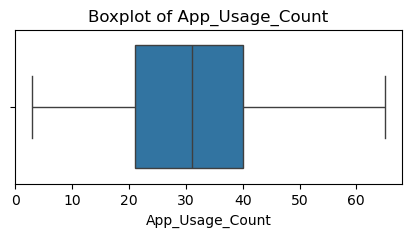

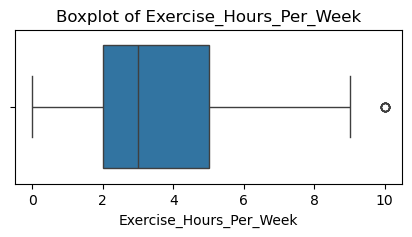

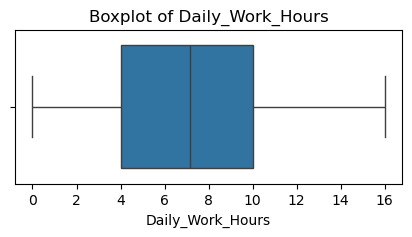

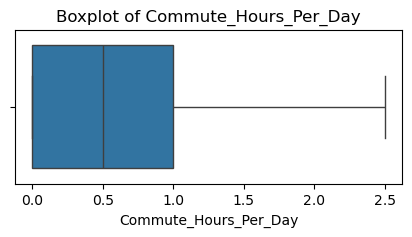

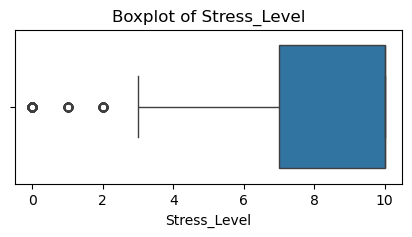

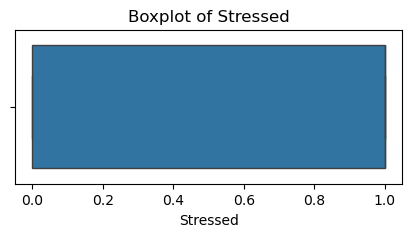

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

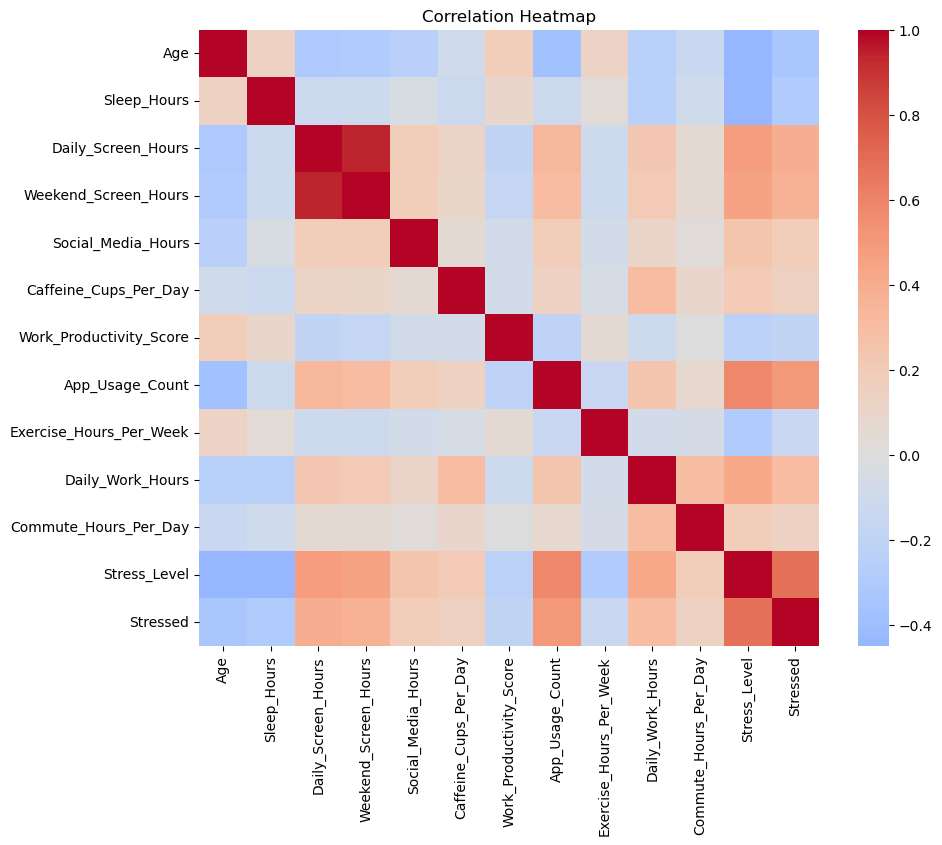

In [9]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# Correlation with stress
stress_corr = corr_matrix["Stress_Level"].sort_values(ascending=False)

print("Correlation with Stress_Level:\n")
print(stress_corr)

Correlation with Stress_Level:

Stress_Level               1.000000
Stressed                   0.685347
App_Usage_Count            0.576390
Daily_Screen_Hours         0.480138
Weekend_Screen_Hours       0.448039
Daily_Work_Hours           0.423347
Social_Media_Hours         0.244425
Caffeine_Cups_Per_Day      0.204752
Commute_Hours_Per_Day      0.187484
Work_Productivity_Score   -0.224907
Exercise_Hours_Per_Week   -0.286427
Age                       -0.445334
Sleep_Hours               -0.449548
Name: Stress_Level, dtype: float64


Top correlated features: Index(['Stressed', 'App_Usage_Count', 'Daily_Screen_Hours', 'Sleep_Hours'], dtype='object')


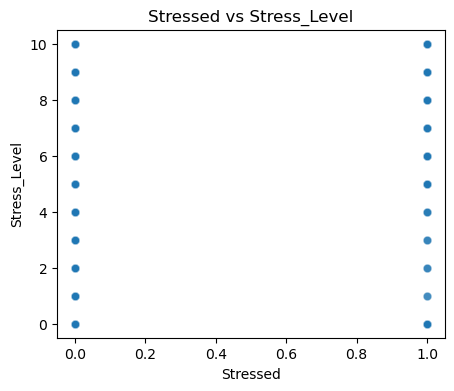

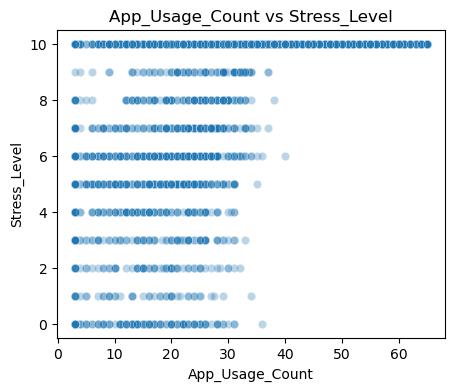

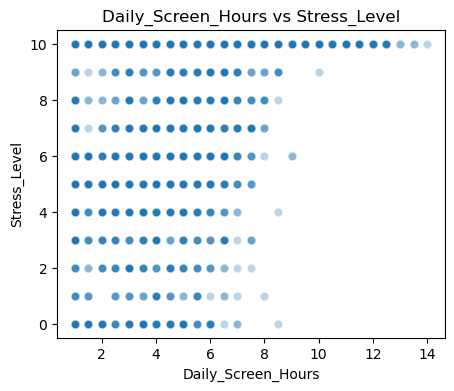

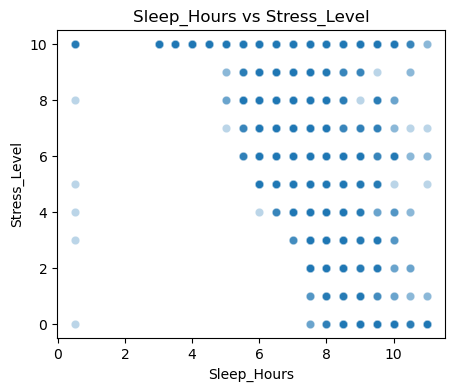

In [11]:
top_features = stress_corr.drop("Stress_Level").abs().sort_values(ascending=False).head(4).index

print("Top correlated features:", top_features)

for feature in top_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[feature], y=df["Stress_Level"], alpha=0.3)
    plt.title(f"{feature} vs Stress_Level")
    plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop target and ID
X = df[numeric_cols].drop(columns=["Stress_Level"])

# Add constant for VIF calculation
X_const = pd.concat([pd.Series(1, index=X.index, name="Intercept"), X], axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

vif_data

,Feature,VIF
0,Intercept,75.097242
1,Age,1.313165
2,Sleep_Hours,1.135781
3,Daily_Screen_Hours,8.939554
4,Weekend_Screen_Hours,8.616653
5,Social_Media_Hours,1.087994
6,Caffeine_Cups_Per_Day,1.117116
7,Work_Productivity_Score,1.080524
8,App_Usage_Count,1.496348
9,Exercise_Hours_Per_Week,1.038352


In [14]:
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=["User_ID", "Gender", "Occupation", "Stress_Level"])
y = df["Stress_Level"]

mi_scores = mutual_info_regression(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False)

mi_df

,Feature,Mutual_Information
11,Stressed,0.358251
7,App_Usage_Count,0.275765
2,Daily_Screen_Hours,0.167827
1,Sleep_Hours,0.160915
0,Age,0.129502
3,Weekend_Screen_Hours,0.122119
9,Daily_Work_Hours,0.101625
8,Exercise_Hours_Per_Week,0.069246
5,Caffeine_Cups_Per_Day,0.041877
4,Social_Media_Hours,0.038937
